# Loading Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import json 
import warnings
warnings.filterwarnings('ignore') # Hide all warnings

In [2]:
df=pd.read_csv('Used_Car_Price_Prediction.csv')

In [3]:
df

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [4]:
df.describe()

,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price,emi_starts_from,booking_down_pymnt
count,7400.000000,7400.000000,7.400000e+03,7400.000000,7400.000000,7.400000e+03,4.120000e+03,7400.000000,7400.000000
mean,2013.885676,62624.520000,4.548892e+05,1550.706081,1.327297,4.322044e+05,5.510351e+05,10565.942027,68233.529054
std,3.087613,43532.042371,2.827023e+05,2080.952842,0.579798,2.880316e+05,3.119887e+05,6566.468434,42405.389468
min,1996.000000,60.000000,0.000000e+00,3.000000,1.000000,0.000000e+00,9.689900e+04,0.000000,0.000000
25%,2012.000000,31885.250000,2.811740e+05,554.750000,1.000000,2.526612e+05,3.414930e+05,6531.250000,42176.250000
50%,2014.000000,55765.000000,3.824490e+05,1088.000000,1.000000,3.611445e+05,4.674800e+05,8883.000000,57367.500000
75%,2016.000000,84184.000000,5.401490e+05,1926.500000,2.000000,5.260180e+05,6.675258e+05,12546.250000,81022.500000
max,2021.000000,996609.000000,3.866000e+06,61930.000000,6.000000,3.250000e+06,2.765057e+06,89798.000000,579901.000000


In [5]:
df.isnull().sum()

car_name                  0
yr_mfr                    0
fuel_type                 0
kms_run                   0
sale_price                0
city                      0
times_viewed              0
body_type               103
transmission            556
variant                   0
assured_buy               0
registered_city          10
registered_state         10
is_hot                    0
rto                       0
source                  126
make                      0
model                     0
car_availability        620
total_owners              0
broker_quote              0
original_price         3280
car_rating                9
ad_created_on             1
fitness_certificate       8
emi_starts_from           0
booking_down_pymnt        0
reserved                  0
warranty_avail            0
dtype: int64

# Data Cleaning

In [6]:
# Remove invalid target rows (price 0 or unrealistically low -> data entry errors)
df = df[df['sale_price'] > 10000].copy()

In [7]:
df

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [8]:
# Remove extreme kms_run outliers (data entry errors, e.g. 996609 kms on a car)
df = df[df['kms_run'] < df['kms_run'].quantile(0.995)]

In [9]:
df

,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [10]:
# Remove sale_price extreme high outliers (top 0.5%) to stop them dominating error metrics
df = df[df['sale_price'] < df['sale_price'].quantile(0.995)]


In [11]:
df


,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,...,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,...,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,...,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,...,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,...,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,...,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7395,honda amaze,2018,diesel,53486,604299,ghaziabad,2756,sedan,NaN,1.5 v cvt i-dtec,...,1,630810,787750.0,great,2021-02-07T08:05:30.443,True,14036,90645,True,False
7396,maruti ignis,2018,petrol,8854,562599,chennai,640,hatchback,manual,delta 1.2 k12,...,1,549440,NaN,great,2021-03-31T10:21:56.289,True,13068,84390,False,False
7397,honda amaze,2015,petrol,46300,400499,pune,795,sedan,manual,1.2 smt i vtec,...,1,383419,NaN,great,2021-03-04T12:40:38.652,True,9303,60075,True,False
7398,maruti alto k10,2016,petrol,27245,284099,new delhi,1155,hatchback,manual,lxi,...,1,286515,369885.0,great,2021-03-16T13:31:39.766,True,6599,42615,False,False


In [12]:
for c in ['body_type', 'transmission', 'source', 'car_availability', 'car_rating', 'fitness_certificate',
          'registered_city', 'registered_state']:
    df[c] = df[c].fillna('unknown')



In [13]:
print("After cleaning shape:", df.shape)


After cleaning shape: (7322, 29)


In [14]:
df.describe()

,yr_mfr,kms_run,sale_price,times_viewed,total_owners,broker_quote,original_price,emi_starts_from,booking_down_pymnt
count,7322.000000,7322.000000,7.322000e+03,7322.000000,7322.000000,7.322000e+03,4.084000e+03,7322.000000,7322.000000
mean,2013.880087,61506.653920,4.460150e+05,1546.355641,1.327096,4.241663e+05,5.424099e+05,10359.815897,66902.393199
std,3.079263,38859.578298,2.514673e+05,2078.314413,0.579390,2.623625e+05,2.889914e+05,5840.958418,37720.136843
min,1996.000000,60.000000,2.000000e+04,3.000000,1.000000,0.000000e+00,9.689900e+04,465.000000,3000.000000
25%,2012.000000,31806.250000,2.807240e+05,556.000000,1.000000,2.524298e+05,3.407792e+05,6520.500000,42108.750000
50%,2014.000000,55539.000000,3.812990e+05,1087.500000,1.000000,3.600000e+05,4.664785e+05,8857.000000,57195.000000
75%,2016.000000,83896.000000,5.374740e+05,1921.000000,2.000000,5.214485e+05,6.635880e+05,12484.250000,80621.250000
max,2021.000000,227391.000000,1.800000e+06,61930.000000,6.000000,1.862999e+06,2.096560e+06,41810.000000,270000.000000


In [15]:
df.isnull().sum()

car_name                  0
yr_mfr                    0
fuel_type                 0
kms_run                   0
sale_price                0
city                      0
times_viewed              0
body_type                 0
transmission              0
variant                   0
assured_buy               0
registered_city           0
registered_state          0
is_hot                    0
rto                       0
source                    0
make                      0
model                     0
car_availability          0
total_owners              0
broker_quote              0
original_price         3238
car_rating                0
ad_created_on             1
fitness_certificate       0
emi_starts_from           0
booking_down_pymnt        0
reserved                  0
warranty_avail            0
dtype: int64

In [16]:
CURRENT_YEAR = 2021  # dataset ads created in 2021
df['car_age'] = CURRENT_YEAR - df['yr_mfr']
df['kms_per_year'] = df['kms_run'] / df['car_age'].replace(0, 1)


In [17]:

# Convert booleans (some may already be bool dtype)
bool_cols = ['assured_buy', 'is_hot', 'reserved', 'warranty_avail']
for c in bool_cols:
    df[c] = df[c].astype(str).map({'True': 1, 'False': 0, 'true': 1, 'false': 0}).fillna(0).astype(int)

df['fitness_certificate'] = df['fitness_certificate'].astype(str).map(
    {'True': 1, 'False': 0, 'true': 1, 'false': 0}).fillna(0).astype(int)


In [18]:
FEATURES_NUM = ['car_age', 'kms_run', 'kms_per_year', 'total_owners', 'times_viewed']
FEATURES_BOOL = ['assured_buy', 'is_hot', 'reserved', 'warranty_avail', 'fitness_certificate']
FEATURES_CAT = ['fuel_type', 'body_type', 'transmission', 'make', 'car_rating', 'registered_state']

TARGET = 'sale_price'

In [24]:
import os

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)

In [25]:

model_df = df[FEATURES_NUM + FEATURES_BOOL + FEATURES_CAT + [TARGET]].copy()
model_df = model_df.dropna()
print("Modeling dataframe shape:", model_df.shape)

Modeling dataframe shape: (7322, 17)


In [26]:
model_df.to_csv('model_df.csv', index=False)
print("Saved cleaned modeling dataframe.")

Saved cleaned modeling dataframe.


# EDA 

In [28]:
df = pd.read_csv('model_df.csv')

In [29]:
df

,car_age,kms_run,kms_per_year,total_owners,times_viewed,assured_buy,is_hot,reserved,warranty_avail,fitness_certificate,fuel_type,body_type,transmission,make,car_rating,registered_state,sale_price
0,6,8063,1343.833333,2,18715,1,1,0,0,1,petrol,hatchback,manual,maruti,great,delhi,386399
1,5,23104,4620.800000,1,2676,1,1,0,0,1,petrol,hatchback,manual,maruti,great,uttar pradesh,265499
2,4,23402,5850.500000,1,609,1,1,0,0,1,petrol,hatchback,manual,hyundai,great,uttar pradesh,477699
3,8,39124,4890.500000,1,6511,1,1,0,0,1,diesel,hatchback,manual,maruti,great,delhi,307999
4,6,22116,3686.000000,1,3225,0,1,0,0,1,petrol,hatchback,manual,hyundai,great,delhi,361499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7317,3,53486,17828.666667,1,2756,1,1,1,0,1,diesel,sedan,unknown,honda,great,uttar pradesh,604299
7318,3,8854,2951.333333,1,640,1,1,0,0,1,petrol,hatchback,manual,maruti,great,tamil nadu,562599
7319,6,46300,7716.666667,1,795,1,1,1,0,1,petrol,sedan,manual,honda,great,maharashtra,400499
7320,5,27245,5449.000000,1,1155,1,1,0,0,1,petrol,hatchback,manual,maruti,great,delhi,284099


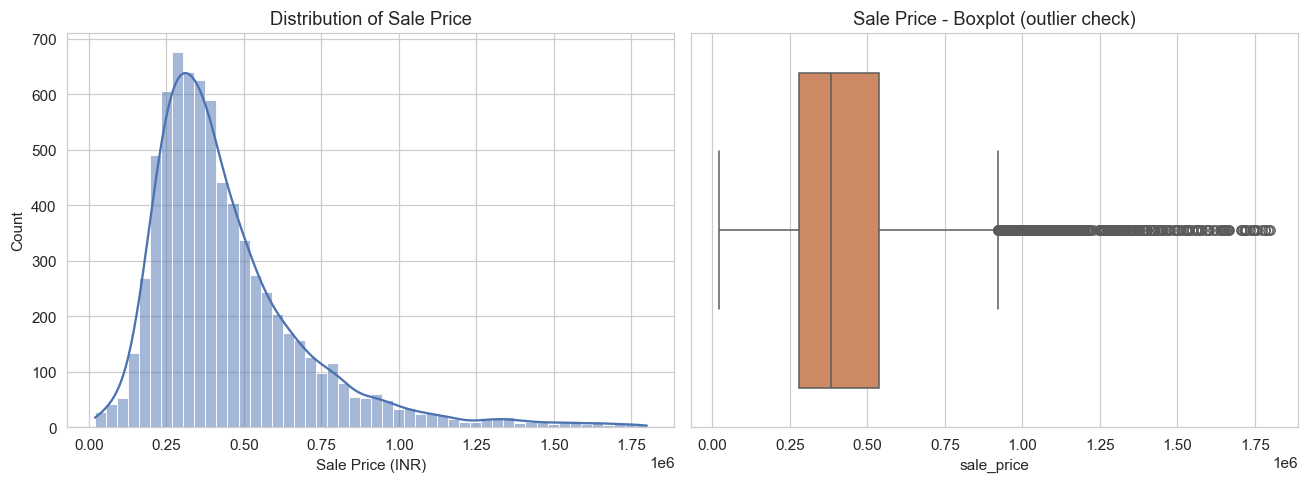

In [37]:
# 1. Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['sale_price'], bins=50, kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Sale Price (INR)')

sns.boxplot(x=df['sale_price'], ax=axes[1], color='#DD8452')
axes[1].set_title('Sale Price - Boxplot (outlier check)')
plt.tight_layout()

plt.savefig(f'{PLOT_DIR}/01_target_distribution.png')
plt.show()
plt.close()

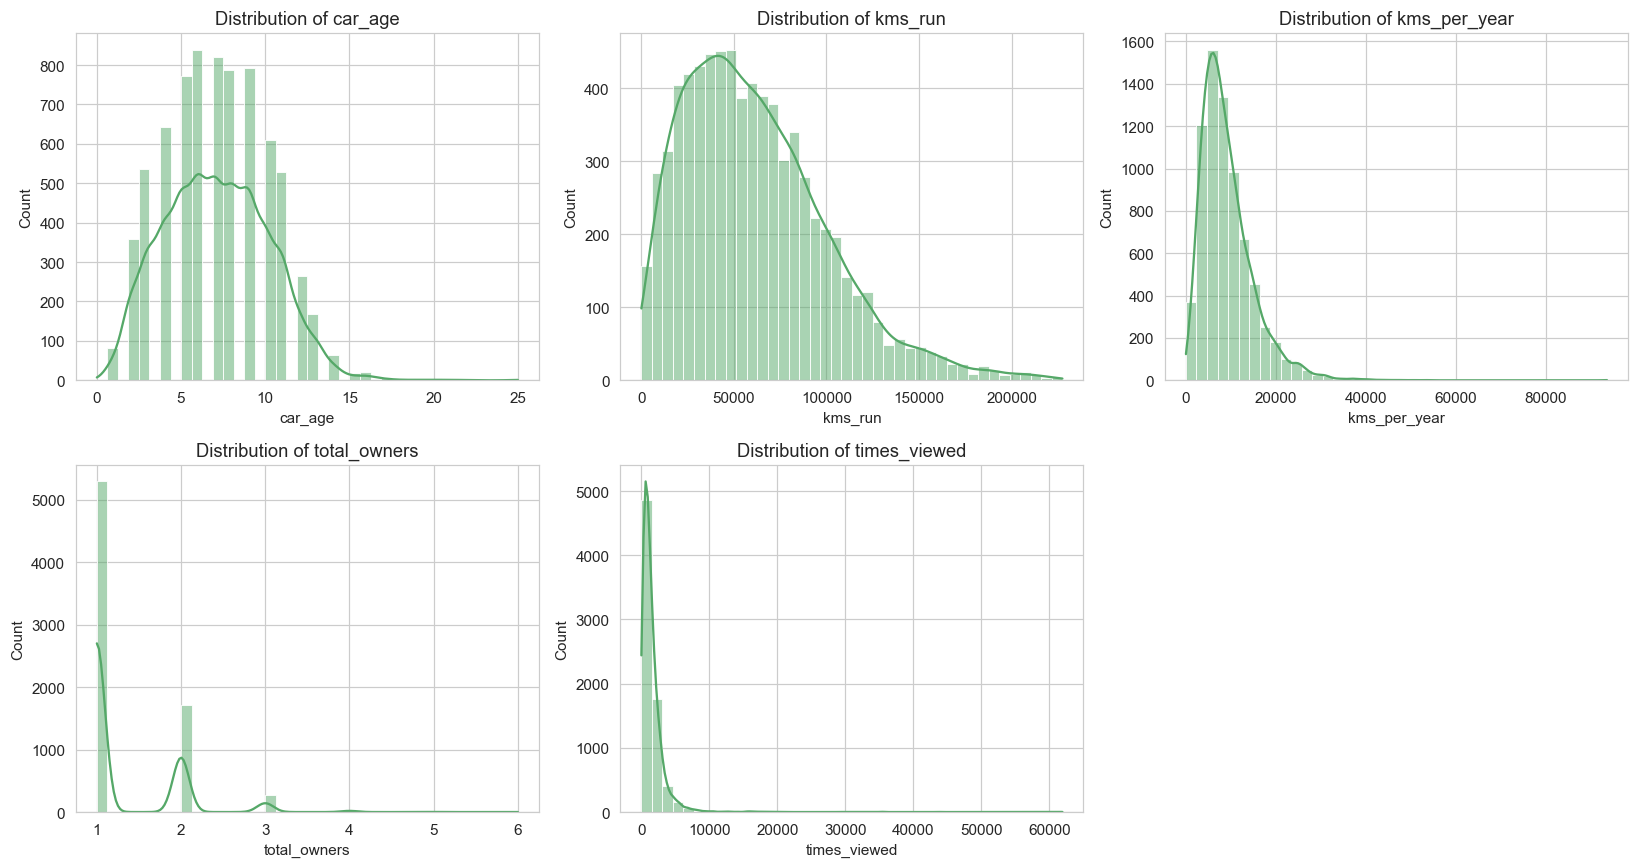

In [41]:
num_cols = ['car_age', 'kms_run', 'kms_per_year', 'total_owners', 'times_viewed']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df[c], bins=40, kde=True, ax=axes[i], color='#55A868')
    axes[i].set_title(f'Distribution of {c}')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_numeric_distributions.png')
plt.show()
plt.close()

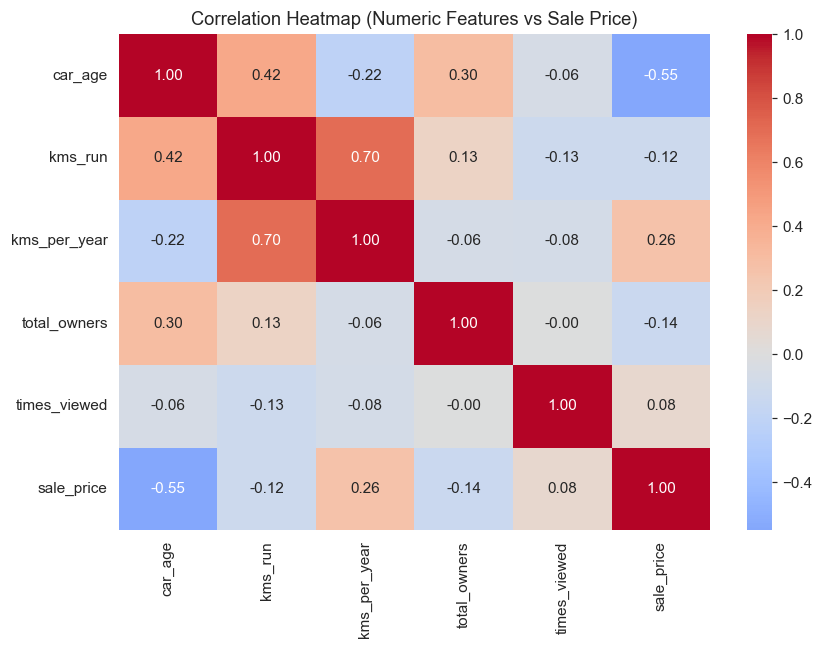

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[num_cols + ['sale_price']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features vs Sale Price)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_correlation_heatmap.png')
plt.show()
plt.close()


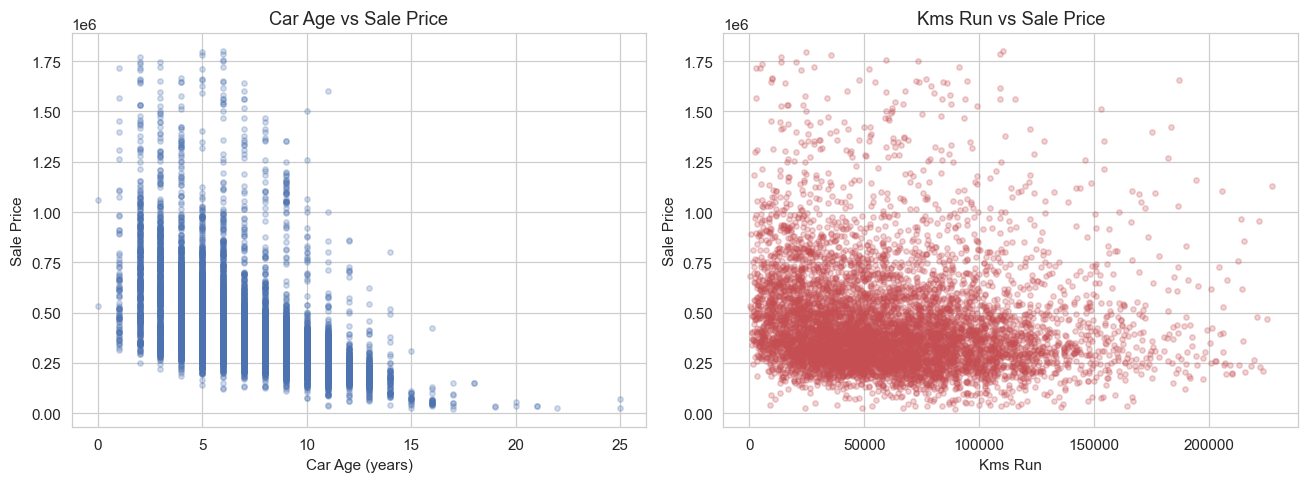

In [42]:
# 4. Scatter: car_age vs price, kms_run vs price
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(df['car_age'], df['sale_price'], alpha=0.25, s=12, color='#4C72B0')
axes[0].set_xlabel('Car Age (years)'); axes[0].set_ylabel('Sale Price')
axes[0].set_title('Car Age vs Sale Price')
axes[1].scatter(df['kms_run'], df['sale_price'], alpha=0.25, s=12, color='#C44E52')
axes[1].set_xlabel('Kms Run'); axes[1].set_ylabel('Sale Price')
axes[1].set_title('Kms Run vs Sale Price')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_scatter_age_kms.png')
plt.show()
plt.close()


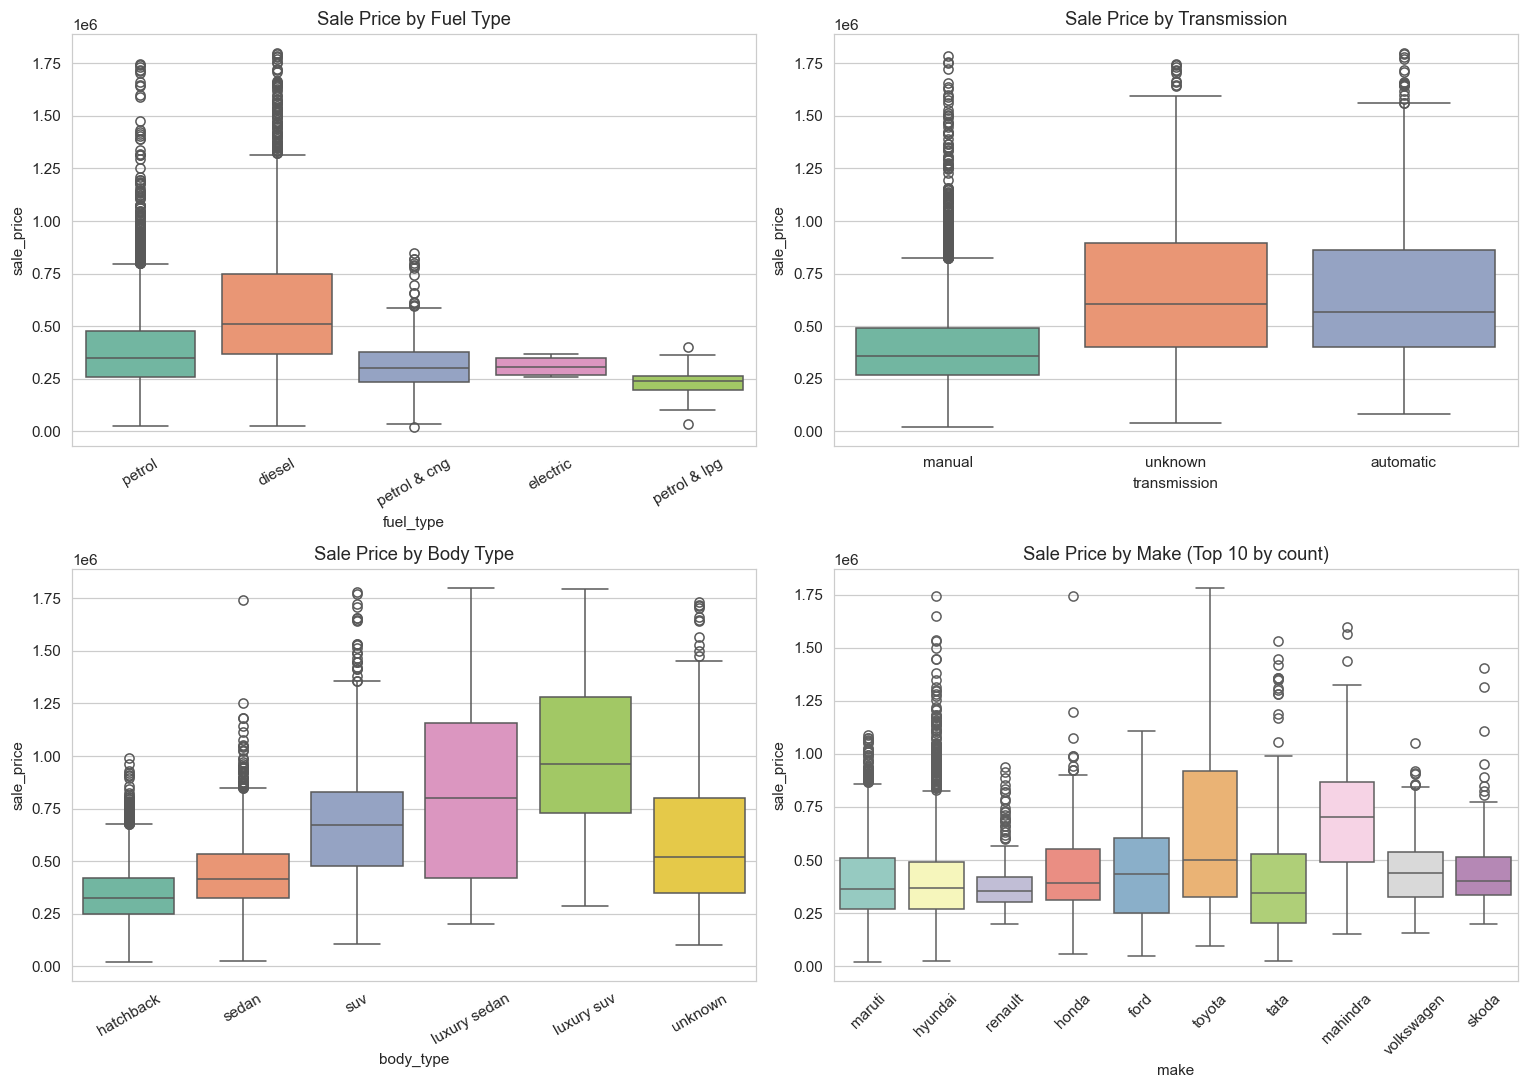

In [43]:
# 5. Categorical: price by fuel_type, transmission, body_type, top makes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df, x='fuel_type', y='sale_price', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Sale Price by Fuel Type')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='transmission', y='sale_price', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Sale Price by Transmission')

sns.boxplot(data=df, x='body_type', y='sale_price', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Sale Price by Body Type')
axes[1, 0].tick_params(axis='x', rotation=30)

top_makes = df['make'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['make'].isin(top_makes)], x='make', y='sale_price', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Sale Price by Make (Top 10 by count)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_categorical_boxplots.png')
plt.show()
plt.close()

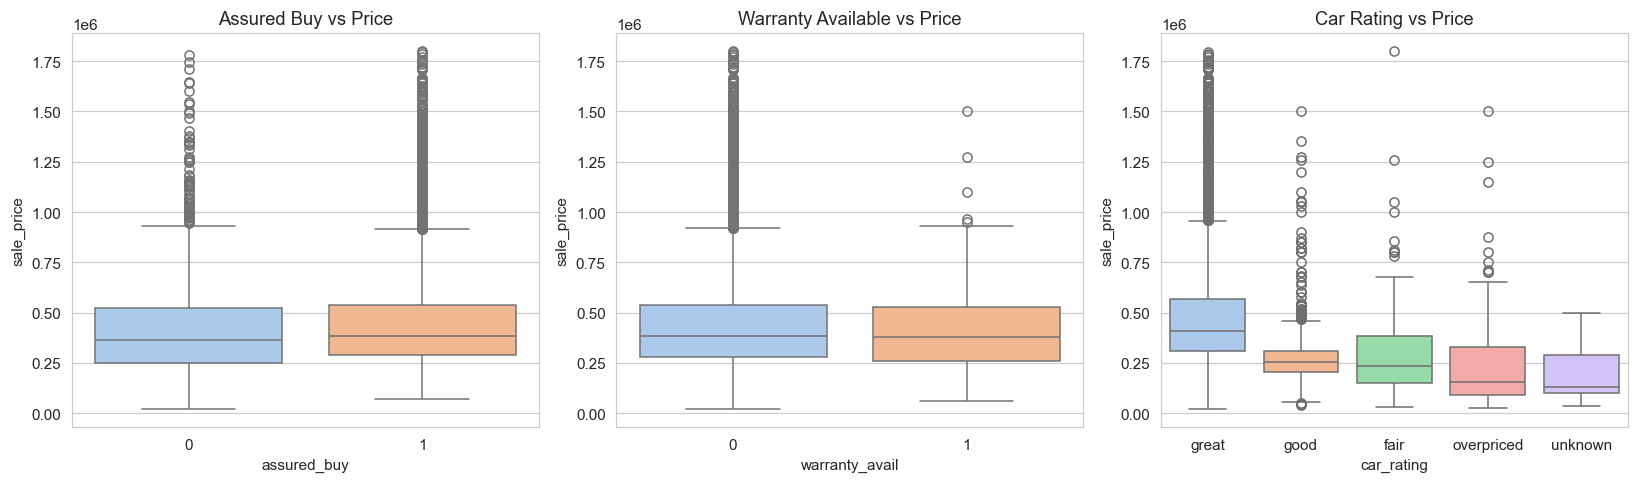

EDA plots saved.


In [44]:
# 6. Boolean flags impact
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x='assured_buy', y='sale_price', ax=axes[0], palette='pastel')
axes[0].set_title('Assured Buy vs Price')
sns.boxplot(data=df, x='warranty_avail', y='sale_price', ax=axes[1], palette='pastel')
axes[1].set_title('Warranty Available vs Price')
sns.boxplot(data=df, x='car_rating', y='sale_price', ax=axes[2], palette='pastel')
axes[2].set_title('Car Rating vs Price')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/06_flags_rating.png')
plt.show()
plt.close()

print("EDA plots saved.")

 # Modeling and Evaulation
